In [1]:
import pandas as pd
import numpy as np
import pickle as pkl
import toolkit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [2]:
with open("data/preprocessed_trainig.pkl", "rb") as file:
    train = pkl.load(file)

In [3]:
train.shape

(17416, 59)

In [4]:
train.head()

,by,.,with,2002,the,of,-0500,to,I,a,...,email,Microsoft,its,>,our,want,<a,.<font,Status,domain
0,5,86,8,7,4,4,2,11,0,6,...,2,0,0,0,1,0,6,3,2,unimportant
1,0,4,3,2,2,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,pobox.com
2,5,18,6,10,9,6,0,9,6,10,...,0,0,0,0,0,0,0,0,0,linux.ie
3,2,12,1,0,6,3,0,3,0,1,...,0,2,0,0,0,0,0,0,2,aol.com
4,4,15,5,9,2,1,0,3,0,0,...,0,0,0,0,0,0,0,0,0,freshrpms.net


In [5]:
ohe = OneHotEncoder(handle_unknown="ignore")

In [6]:
X_train, y_train = train.drop("Status", axis=1), train["Status"] 

In [7]:
X_train.head()

,by,.,with,2002,the,of,-0500,to,I,a,...,your,email,Microsoft,its,>,our,want,<a,.<font,domain
0,5,86,8,7,4,4,2,11,0,6,...,2,2,0,0,0,1,0,6,3,unimportant
1,0,4,3,2,2,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,pobox.com
2,5,18,6,10,9,6,0,9,6,10,...,0,0,0,0,0,0,0,0,0,linux.ie
3,2,12,1,0,6,3,0,3,0,1,...,1,0,2,0,0,0,0,0,0,aol.com
4,4,15,5,9,2,1,0,3,0,0,...,0,0,0,0,0,0,0,0,0,freshrpms.net


In [8]:
del train

In [9]:
ct = ColumnTransformer(
    [
        ("ohe", OneHotEncoder(handle_unknown="ignore"), ["domain"]),
        ("scalling", StandardScaler(), X_train.columns[:-1])
    ]
)

In [10]:
ct.fit(X_train)

ColumnTransformer(transformers=[('ohe', OneHotEncoder(handle_unknown='ignore'),
                                 ['domain']),
                                ('scalling', StandardScaler(),
                                 Index(['by', '.', 'with', '2002', 'the', 'of', '-0500', 'to', 'I', 'a', 'that',
       'it', '.>', 'is', '+0100', '.Received:', 'ESMTP', 'id', 'Linux', 'and',
       '.Content-Type', '.Sender:', '.Errors-To:', '.X-Mailman-Version:',
       '.Precedence:', 'bulk', '.List-Id', '.X-Beenthere', '(Postfix)',
       'using', '.Delivered-To:', 'or', '<jm@localhost>;', '-0400', 'IMAP',
       '(fethmail-5.9.0)', 'jm@localhost', '(single-drop);', '(IST)', 'you',
       '(PDT)', '-0700', '[127.0.0.1]', 'SMTP', '(jalapeno', 'in',
       '.Content-Transfer-Encoding:', 'will', 'your', 'email', 'Microsoft',
       'its', '>', 'our', 'want', '<a', '.<font'],
      dtype='object'))])

In [11]:
X_train = ct.transform(X_train)

In [12]:
with open("./pickled_objects/columnTransformer.pkl", "wb") as file:
    pkl.dump(ct, file)

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, stratify=y_train)

In [14]:
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((13062, 81), (13062,), (4354, 81), (4354,))

In [15]:
y_train = (y_train == 2)
y_valid = (y_valid == 2)

# Modelling
## Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l2", None],
        "solver" : ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"],
        "max_iter" : [20, 50, 100, 200]
    },
    cv=5,
    n_jobs=-1
)

In [18]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': [20, 50, 100, 200],
                         'penalty': ['l2', None],
                         'solver': ['lbfgs', 'newton-cg', 'newton-cholesky',
                                    'sag', 'saga']})

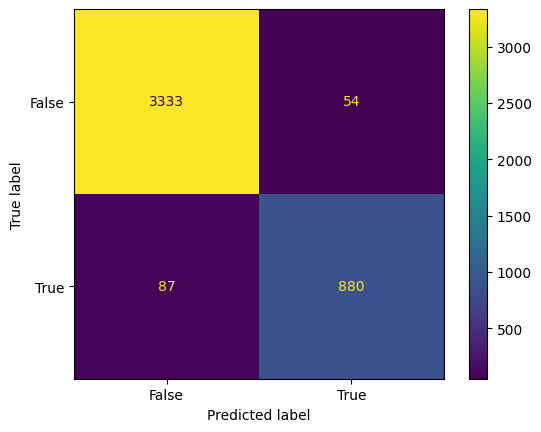

In [19]:
lr = gs.best_estimator_
y_pred_valid = lr.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [20]:
print(classification_report(y_pred=y_pred_valid, y_true=y_valid))

              precision    recall  f1-score   support

       False       0.97      0.98      0.98      3387
        True       0.94      0.91      0.93       967

    accuracy                           0.97      4354
   macro avg       0.96      0.95      0.95      4354
weighted avg       0.97      0.97      0.97      4354



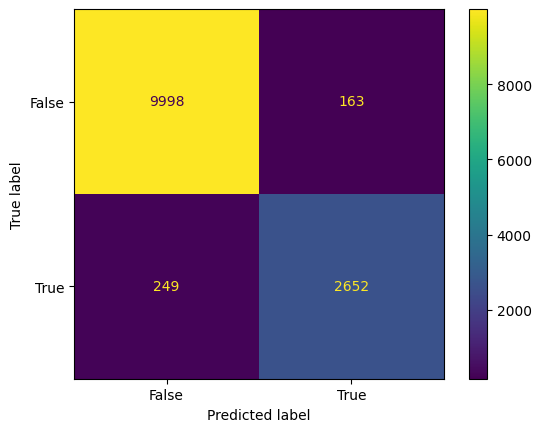

In [21]:
lr = gs.best_estimator_
y_pred_valid = lr.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_true=y_train, y_pred=y_pred_valid)

In [29]:
print(classification_report(y_pred=y_pred_valid, y_true=y_train))

              precision    recall  f1-score   support

       False       0.98      0.98      0.98     10161
        True       0.94      0.91      0.93      2901

    accuracy                           0.97     13062
   macro avg       0.96      0.95      0.95     13062
weighted avg       0.97      0.97      0.97     13062



In [22]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l2", "l1"],
        "solver" : ["liblinear", "saga"],
        "max_iter" : [20, 30, 40, 50, 100, 200]
    },
    cv=5,
    n_jobs=-1
)

In [23]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': [20, 30, 40, 50, 100, 200],
                         'penalty': ['l2', 'l1'],
                         'solver': ['liblinear', 'saga']})

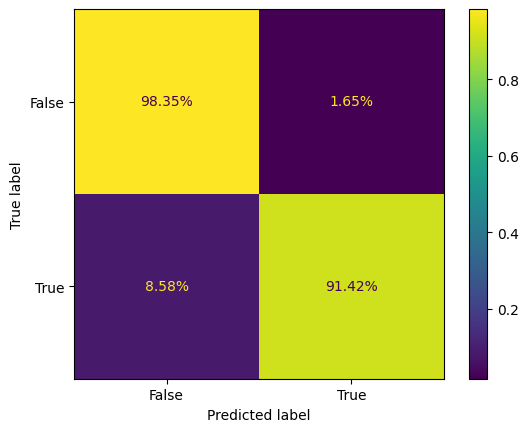

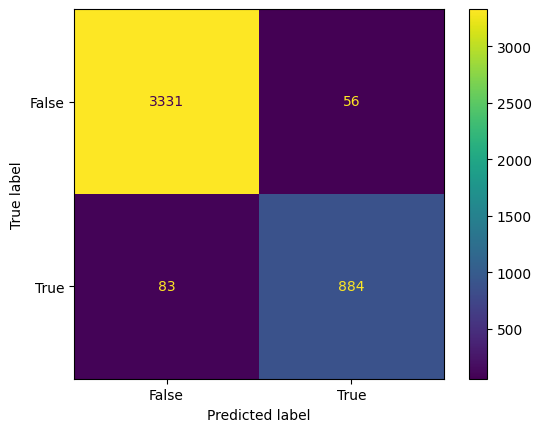

In [24]:
lr2 = gs.best_estimator_
y_pred_valid2 = lr2.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2)

In [25]:
print(classification_report(y_pred=y_pred_valid2, y_true=y_valid))

              precision    recall  f1-score   support

       False       0.98      0.98      0.98      3387
        True       0.94      0.91      0.93       967

    accuracy                           0.97      4354
   macro avg       0.96      0.95      0.95      4354
weighted avg       0.97      0.97      0.97      4354



In [26]:
y_pred_valid = lr.predict(X_valid)

In [27]:
np.mean(y_pred_valid == y_valid), np.mean(y_pred_valid2 == y_valid)

(np.float64(0.9676159853008728), np.float64(0.9680753330271015))

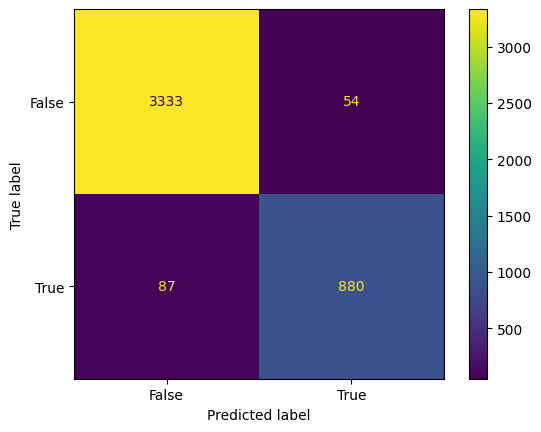

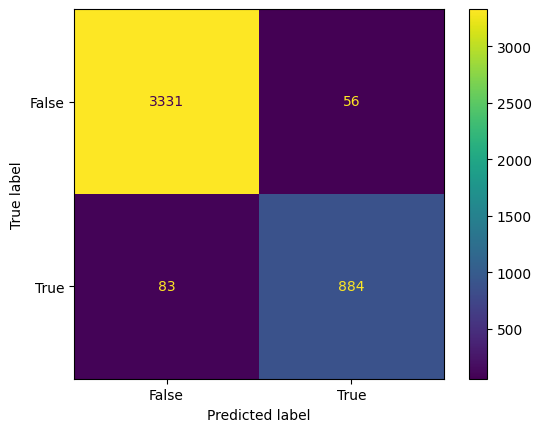

In [28]:
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2)

In [30]:
lr, lr2

(LogisticRegression(max_iter=20, random_state=42, solver='newton-cholesky'),
 LogisticRegression(max_iter=40, penalty='l1', random_state=42,
                    solver='liblinear'))

In [31]:
lr.penalty

'l2'

In [32]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l2"],
        "solver" : ["newton-cholesky"],
        "max_iter" : np.arange(10, 30)
    },
    cv=3,
    n_jobs=-1
)
gs.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29]),
                         'penalty': ['l2'], 'solver': ['newton-cholesky']})

In [33]:
gs = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid={
        "penalty" : ["l2"],
        "solver" : ["newton-cholesky"],
        "max_iter" : np.arange(1, 11)
    },
    cv=3,
    n_jobs=-1
)
gs.fit(X_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:431: ConvergenceWarning: Newton solver did not converge after 5 iterations.
  warnings.warn(


GridSearchCV(cv=3, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'penalty': ['l2'], 'solver': ['newton-cholesky']})

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:431: ConvergenceWarning: Newton solver did not converge after 5 iterations.
  warnings.warn(


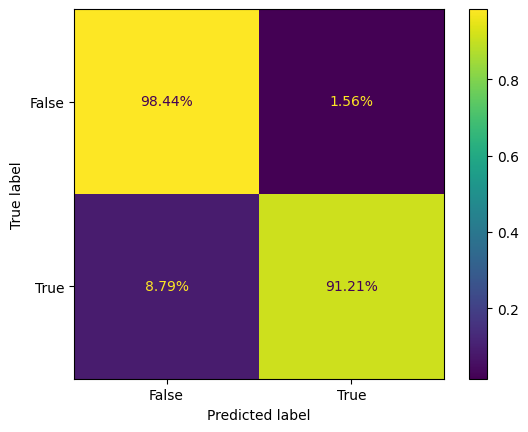

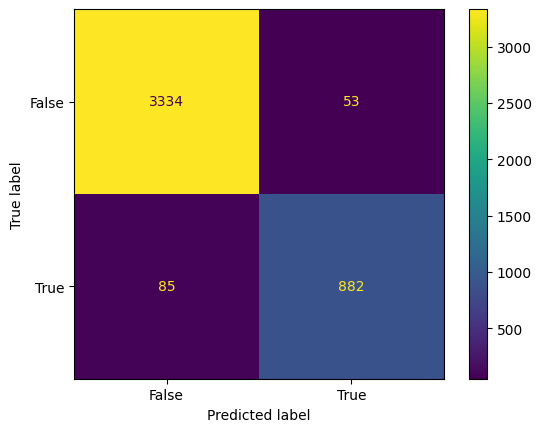

In [34]:
lr = gs.best_estimator_
lr.fit(X_train, y_train)
y_pred_valid2 = lr.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid2)

In [35]:
model = LogisticRegression(max_iter = 50, penalty=None, random_state=42,solver="newton-cg")
model.fit(X_train, y_train)
with open("models/LogisticRegressor.pkl", "wb") as file:
    pkl.dump(model, file)

model = LogisticRegression(max_iter=30, penalty="l1", random_state=42, solver="liblinear")
model.fit(X_train, y_train)
with open("models/LogisticRegressor2.pkl", "wb") as file:
    pkl.dump(model, file)

### Results
As we can see, the difference is not tha much but the 2nd classfier has smaller recall which may be a disadvantage in this case.

## K Nearest Neighbours

In [36]:
from sklearn.neighbors import KNeighborsClassifier

In [37]:
gs = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid={
        "n_neighbors" : np.arange(1, 7, 1),
        "weights" : ["uniform", "distance"],
        "metric" : ["l1", "l2", "cosine"]
    },
    n_jobs=-1,
    cv=3
)

In [38]:
X_train.shape

(13062, 81)

In [39]:
gs.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(n_jobs=-1), n_jobs=-1,
             param_grid={'metric': ['l1', 'l2', 'cosine'],
                         'n_neighbors': array([1, 2, 3, 4, 5, 6]),
                         'weights': ['uniform', 'distance']})

In [40]:
knn = gs.best_estimator_

In [41]:
knn.weights

'uniform'

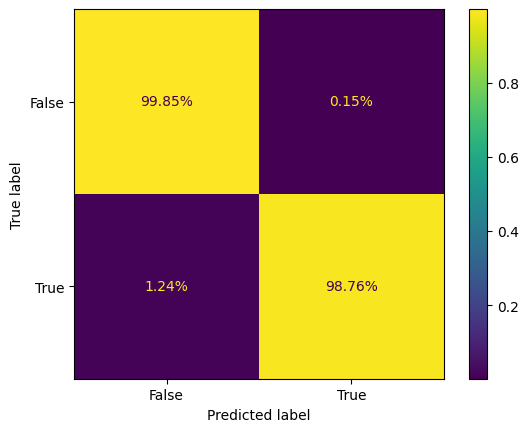

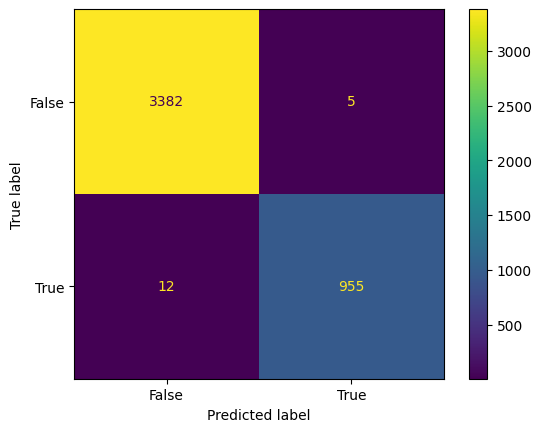

In [42]:
y_pred_valid = knn.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [43]:
print(classification_report(y_pred=y_pred_valid, y_true=y_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       1.00      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



In [44]:
np.mean(y_pred_valid==y_valid)

np.float64(0.9960955443270556)

In [45]:
with open("models/KNNClassifier.pkl", "wb") as file:
    model = KNeighborsClassifier(n_neighbors=1, weights="uniform", metric="l1")
    model.fit(X_train, y_train)
    pkl.dump(model, file)

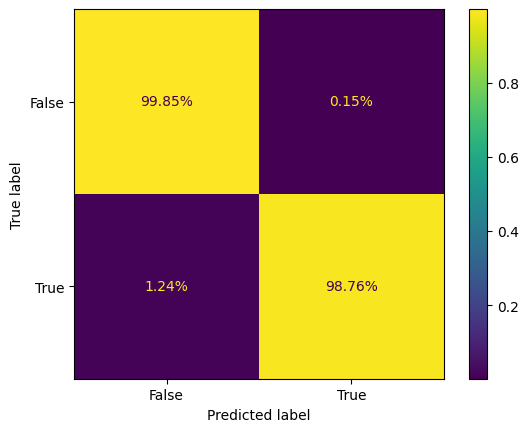

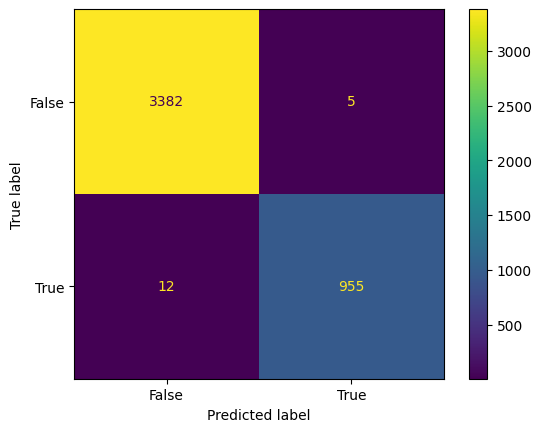

In [46]:
y_pred_valid = model.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

### Results
Great succes, I guess. Probalty it's an effect of cruciality of domains, from where the e-mails are sent.

## Decision Trees

In [47]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
gs = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini"],
        "max_depth" : [10, 20, 30, 50, 100],
        "min_samples_split" : np.arange(2, 6, 1),
    },
    cv=3,
    n_jobs=-1
)

In [53]:
gs.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': [10, 20, 30, 50, 100],
                         'min_samples_split': array([2, 3, 4, 5])})

In [54]:
gss = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini"],
        "max_depth" : np.arange(50, 151, 10),
        "min_samples_split" : np.arange(2, 5, 1)
    },
    cv=3,
    n_jobs=-1
)

In [55]:
gss.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': array([ 50,  60,  70,  80,  90, 100, 110, 120, 130, 140, 150]),
                         'min_samples_split': array([2, 3, 4])})

In [56]:
gss = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini"],
        "max_depth" : np.arange(120, 141, 1),
        "min_samples_split" : np.arange(2, 6, 1)
    },
    cv=3,
    n_jobs=-1
)

In [57]:
gss.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': array([120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
       133, 134, 135, 136, 137, 138, 139, 140]),
                         'min_samples_split': array([2, 3, 4, 5])})

In [58]:
dc = gss.best_estimator_

In [59]:
dc.criterion

'gini'

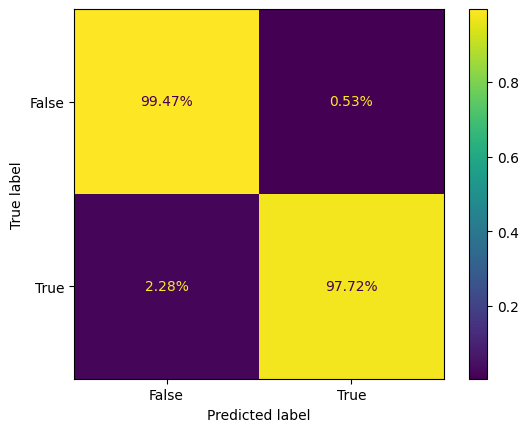

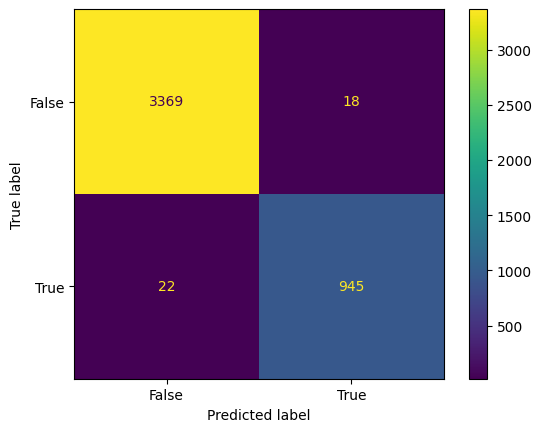

In [60]:
dc = gs.best_estimator_
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

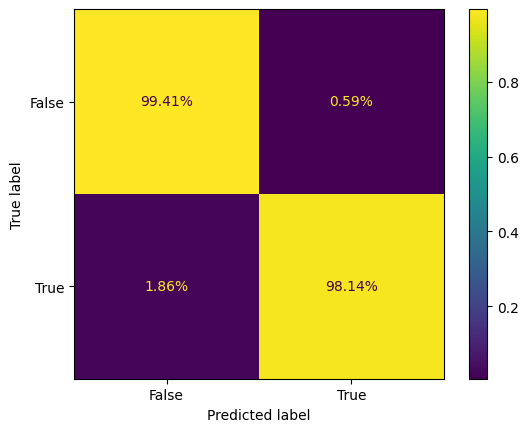

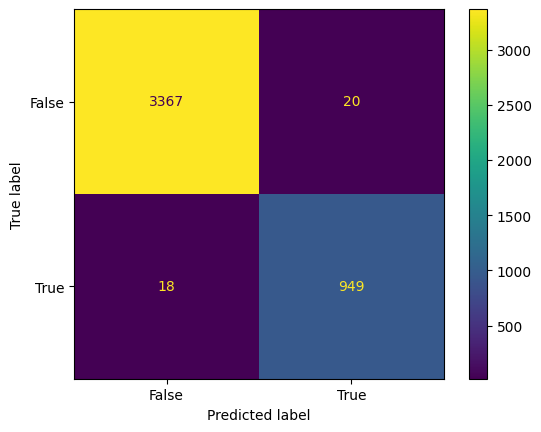

In [61]:
dc = gss.best_estimator_
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [62]:
print(classification_report(y_pred=y_pred_valid, y_true=y_valid))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99      3387
        True       0.98      0.98      0.98       967

    accuracy                           0.99      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       0.99      0.99      0.99      4354



In [63]:
np.mean(y_pred_valid == y_valid)

np.float64(0.9912723932016536)

In [66]:
gss = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid={
        "criterion" : ["gini"],
        "max_depth" : np.arange(20, 41, 1),
        "min_samples_split" : np.arange(2, 4, 1)
    },
    cv=3,
    n_jobs=-1
)
gss.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40]),
                         'min_samples_split': array([2, 3])})

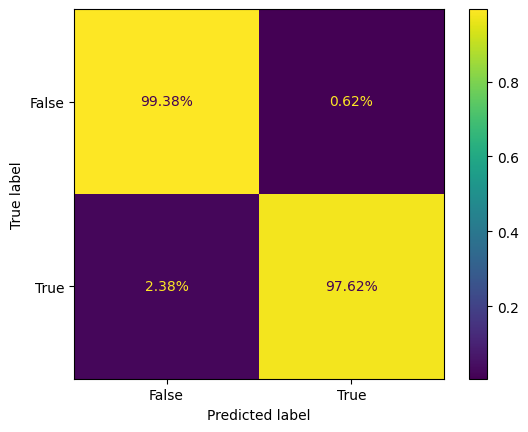

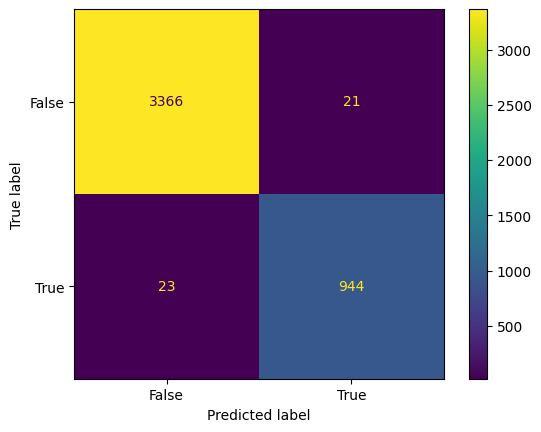

In [67]:
dc = gss.best_estimator_
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

In [68]:
with open("models/DecisionTree.pkl", "wb") as file:
    model = gss.best_estimator_
    model.fit(X_train, y_train)
    pkl.dump(model, file)

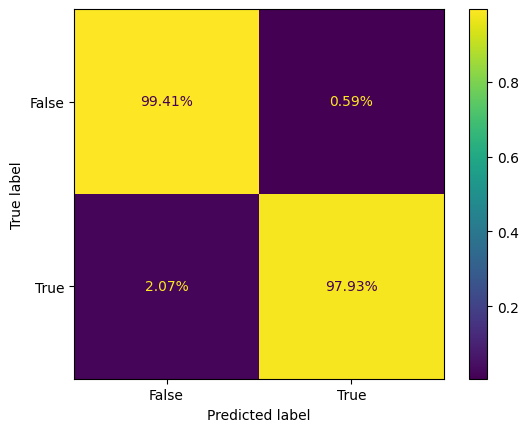

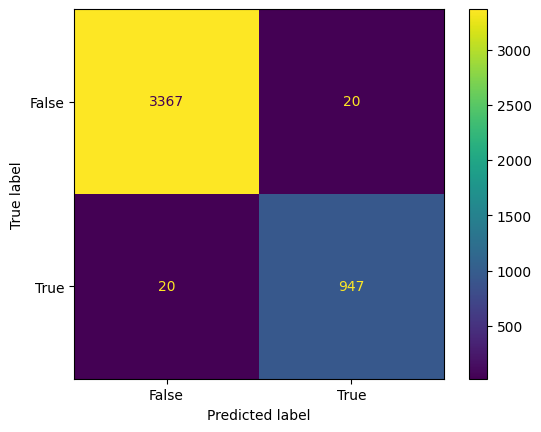

In [69]:
dc = model
y_pred_valid = dc.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)

### Results
Again, we achieved high scores. Interesingly, with max_depth = 50 the bese min_leaf_size was 1, which is similar to KNearestNeighboursClassifier with the best n_neighbour=1 param.

## Random Forest

In [70]:
from sklearn.ensemble import RandomForestClassifier

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



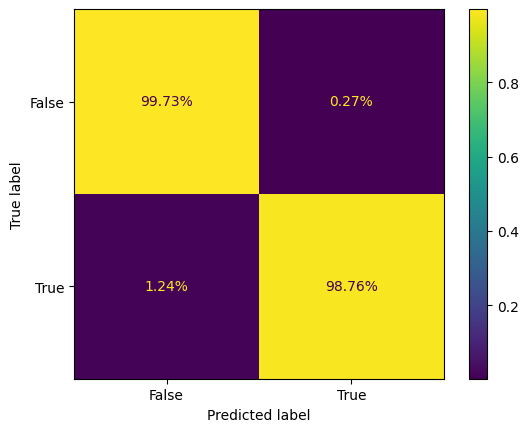

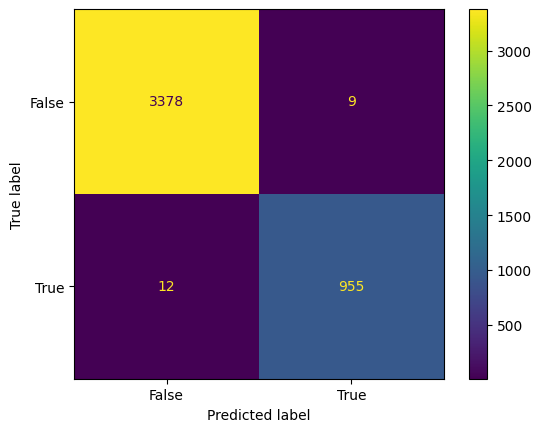

In [71]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=200)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid, normalize="true", values_format=".2%")
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



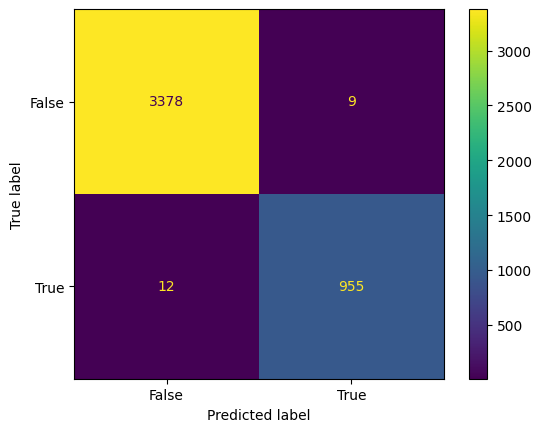

In [72]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=500)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           0.99      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       0.99      0.99      0.99      4354



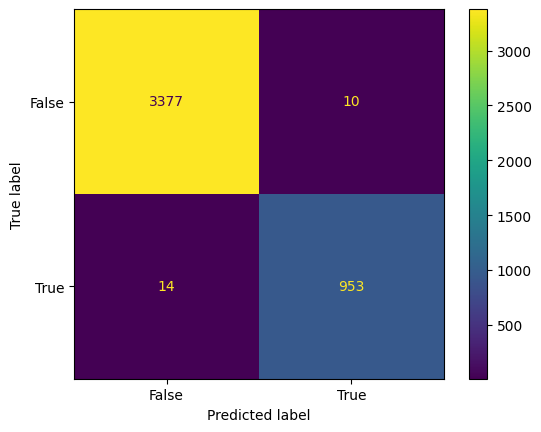

In [73]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=30)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



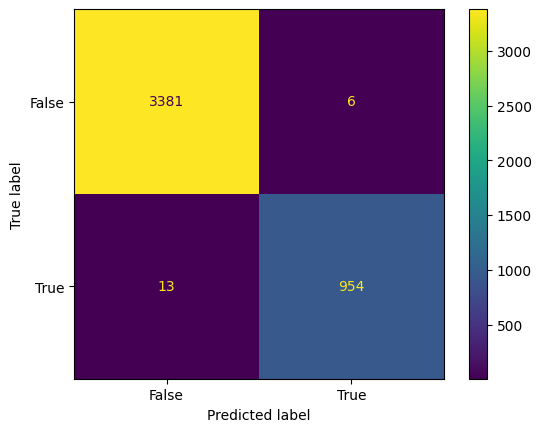

In [74]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=20)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



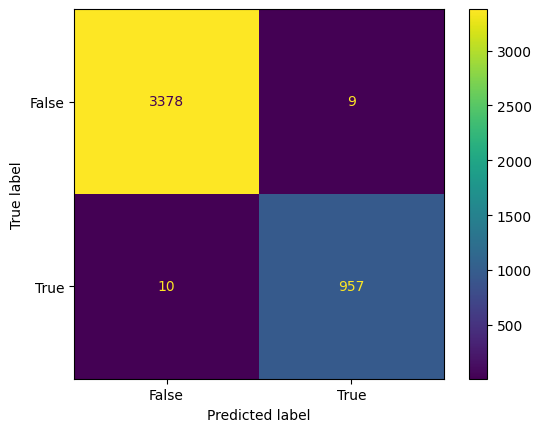

In [75]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=None, n_estimators=50)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



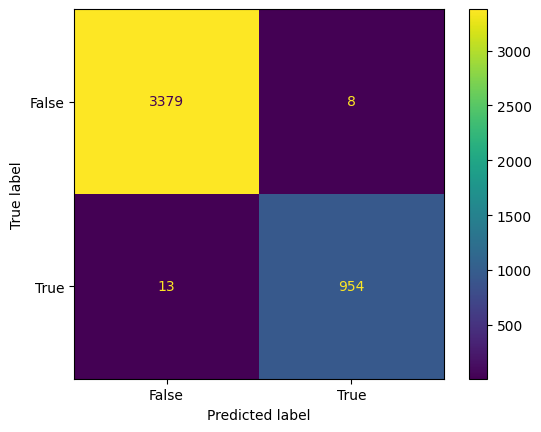

In [76]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=18)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



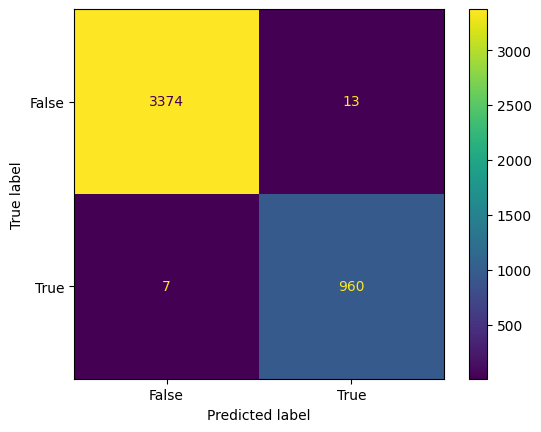

In [33]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=94, n_estimators=26)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [34]:
with open("models/RandomForest.pkl", "wb") as file:
    pkl.dump(rf, file)

### The Second Attempt

In [77]:
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, min_samples_split=3),
    param_grid={
        "n_estimators" : np.arange(10, 31, 2),
        "criterion" : ["gini"],
        "max_depth" : [None] + list(np.arange(80, 101, 4))
    },
    cv=3,
    n_jobs=-1,
    verbose=1,
)

In [78]:
gs.fit(X_train, y_train)

Fitting 3 folds for each of 77 candidates, totalling 231 fits


GridSearchCV(cv=3,
             estimator=RandomForestClassifier(min_samples_split=3, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': [None, np.int64(80), np.int64(84),
                                       np.int64(88), np.int64(92), np.int64(96),
                                       np.int64(100)],
                         'n_estimators': array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30])},
             verbose=1)

In [81]:
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators" : np.arange(14, 23, 1),
        "criterion" : ["gini"],
        "max_depth" : [None],
        "min_samples_split" : np.arange(2, 6, 1)
    },
    cv=3,
    n_jobs=-1,
    verbose=1,
)

In [82]:
gs.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini'], 'max_depth': [None],
                         'min_samples_split': array([2, 3, 4, 5]),
                         'n_estimators': array([14, 15, 16, 17, 18, 19, 20, 21, 22])},
             verbose=1)

In [83]:
gs.best_estimator_

RandomForestClassifier(min_samples_split=np.int64(2), n_estimators=np.int64(19),
                       n_jobs=-1, random_state=42)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           0.99      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       0.99      0.99      0.99      4354



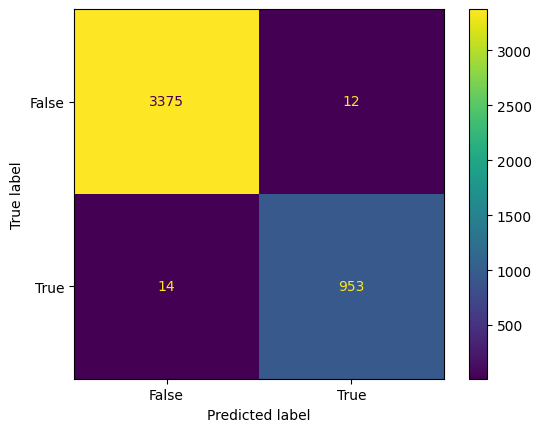

In [89]:
rf = gs.best_estimator_
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [85]:
rf.max_depth

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           0.99      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       0.99      0.99      0.99      4354



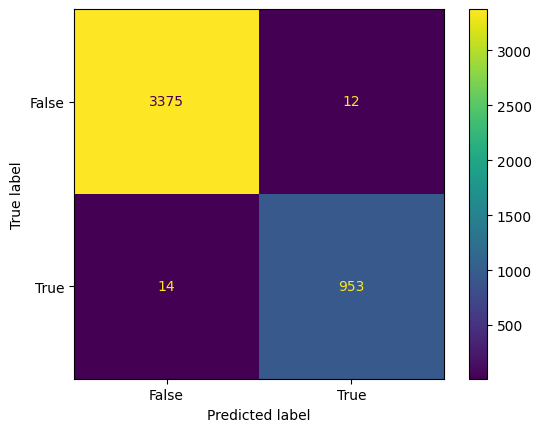

In [86]:
rf = RandomForestClassifier(min_samples_split=2, n_estimators=19, max_depth=None, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [71]:
np.mean(y_valid==y_pred_valid)

np.float64(0.9947175011483693)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



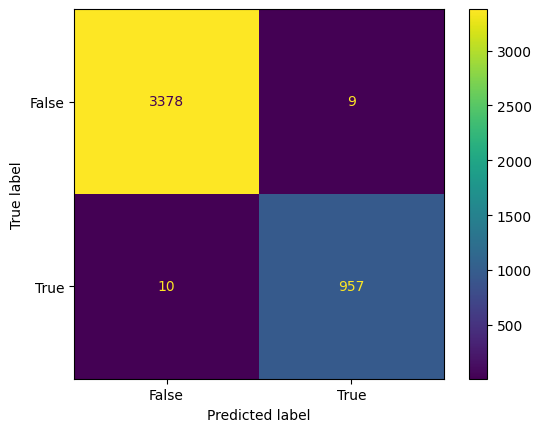

In [90]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=None, n_estimators=50)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [101]:
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators" : np.arange(45, 55, 1),
        "criterion" : ["gini"],
        "max_depth" : [None] + list(np.arange(90, 101, 4)),
        "min_samples_split" : np.arange(2, 4, 1)
    },
    cv=5,
    n_jobs=-1,
    verbose=1,
)

In [102]:
gs.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini'],
                         'max_depth': [None, np.int64(90), np.int64(94),
                                       np.int64(98)],
                         'min_samples_split': array([2, 3]),
                         'n_estimators': array([45, 46, 47, 48, 49, 50, 51, 52, 53, 54])},
             verbose=1)

In [103]:
gs.best_estimator_.max_depth

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           0.99      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       0.99      0.99      0.99      4354



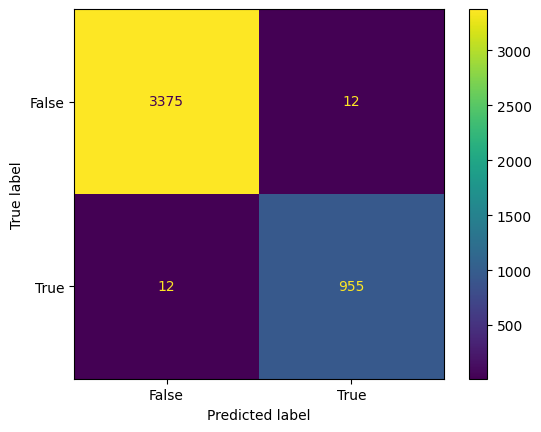

In [104]:
rf = gs.best_estimator_
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           0.99      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       0.99      0.99      0.99      4354



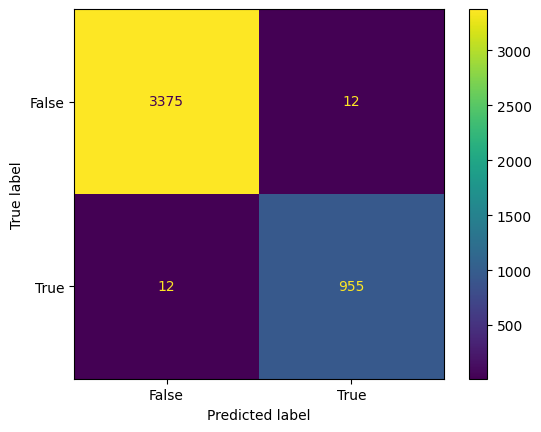

In [110]:
rf = RandomForestClassifier(random_state=42, min_samples_split=2, max_depth=None, n_estimators=54, criterion="gini")
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [111]:
with open("models/RandomForest2.pkl", "wb") as file:
    pkl.dump(rf, file)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3387
        True       0.99      0.99      0.99       967

    accuracy                           1.00      4354
   macro avg       0.99      0.99      0.99      4354
weighted avg       1.00      1.00      1.00      4354



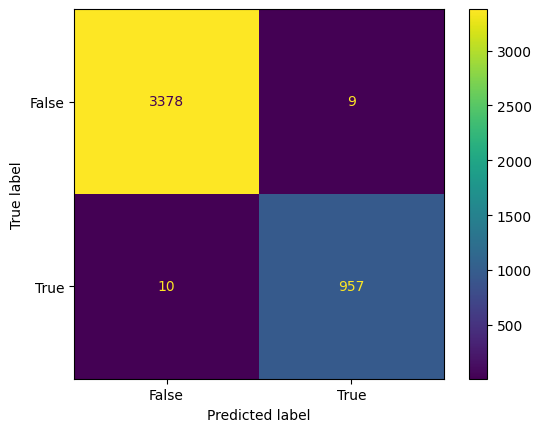

In [112]:
rf = RandomForestClassifier(random_state=42, min_samples_leaf=1, min_samples_split=3, max_depth=None, n_estimators=50)
rf.fit(X_train, y_train)
y_pred_valid = rf.predict(X_valid)
ConfusionMatrixDisplay.from_predictions(y_true=y_valid, y_pred=y_pred_valid)
print(classification_report(y_true=y_valid, y_pred=y_pred_valid))

In [113]:
with open("models/RandomForest3.pkl", "wb") as file:
    pkl.dump(rf, file)